In [1]:
import os
import cv2
import re
import numpy as np
import matplotlib.pyplot as plt
import warnings
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
plt.style.use('default')

In [2]:
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

def compute_tsr_derivatives(thermal_seq, poly_degree=5):
    T, H, W = thermal_seq.shape
    time_steps = np.arange(1, T + 1)
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        log_t = np.log(time_steps)
        log_T_flat = np.log(np.maximum(thermal_seq.reshape(T, -1), 1e-6))

    print(f"Fitting Polynomials (Degree {poly_degree}) across {H*W} pixels...")
    coeffs = np.polyfit(log_t, log_T_flat, deg=poly_degree)
    
    powers_d1 = np.arange(poly_degree, 0, -1)[:, np.newaxis]
    d1_coeffs = coeffs[:-1] * powers_d1
    
    powers_d2 = np.arange(poly_degree - 1, 0, -1)[:, np.newaxis]
    d2_coeffs = d1_coeffs[:-1] * powers_d2
    
    d1_frames, d2_frames = [], []

    for t_val in log_t:
        f1 = np.zeros(H * W)
        for c in d1_coeffs: 
            f1 = f1 * t_val + c
        d1_frames.append(f1.reshape(H, W))
        
        f2 = np.zeros(H * W)
        for c in d2_coeffs: 
            f2 = f2 * t_val + c
        d2_frames.append(f2.reshape(H, W))
        
    return np.stack(d1_frames).astype(np.float32), np.stack(d2_frames).astype(np.float32)

In [3]:
dataset_path = "./dataset/" 
orig_dir = os.path.join(dataset_path, 'originalData')
mask_dir = os.path.join(dataset_path, 'annotatedData')

orig_files = sorted([f for f in os.listdir(orig_dir) if not f.startswith('.')], key=natural_sort_key)
mask_files = sorted([f for f in os.listdir(mask_dir) if not f.startswith('.')], key=natural_sort_key)

thermal_list, mask_list = [], []

In [4]:
for fname in orig_files:
    img = cv2.imread(os.path.join(orig_dir, fname), cv2.IMREAD_GRAYSCALE)
    m_img = cv2.imread(os.path.join(mask_dir, fname), cv2.IMREAD_GRAYSCALE)
    
    thermal_list.append(img)
    
    _, binary = cv2.threshold(m_img, 1, 255, cv2.THRESH_BINARY)
    mask_list.append(binary / 255.0)

In [5]:
thermal_volume = np.stack(thermal_list, axis=0).astype(np.float32)
mask_volume = np.stack(mask_list, axis=0).astype(np.float32)

tsr_d1, tsr_d2 = compute_tsr_derivatives(thermal_volume)

Fitting Polynomials (Degree 5) across 54756 pixels...


In [6]:
class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias=True):
        super(ConvLSTMCell, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.kernel_size = kernel_size
        self.padding = kernel_size[0] // 2, kernel_size[1] // 2
        self.bias = bias
        
        self.conv = nn.Conv2d(in_channels=self.input_dim + self.hidden_dim,
                              out_channels=4 * self.hidden_dim,
                              kernel_size=self.kernel_size,
                              padding=self.padding,
                              bias=self.bias)

    def forward(self, input_tensor, cur_state):
        h_cur, c_cur = cur_state
        combined = torch.cat([input_tensor, h_cur], dim=1)  
        combined_conv = self.conv(combined)
        
        cc_i, cc_f, cc_o, cc_g = torch.split(combined_conv, self.hidden_dim, dim=1)
        i = torch.sigmoid(cc_i)
        f = torch.sigmoid(cc_f)
        o = torch.sigmoid(cc_o)
        g = torch.tanh(cc_g)
        
        c_next = f * c_cur + i * g
        h_next = o * torch.tanh(c_next)
        
        return h_next, c_next

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), 
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), 
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

In [7]:
class ConvLSTMUNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1):
        super().__init__()
        self.inc = DoubleConv(in_ch, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        
        self.convlstm = ConvLSTMCell(input_dim=256, hidden_dim=256, kernel_size=(3, 3))
        
        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(256, 128)
        
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(128, 64)
        
        self.outc = nn.Conv2d(64, out_ch, kernel_size=1)

    def forward(self, x):
        B, T, C, H, W = x.size()
        h_state, c_state = None, None
        outputs = []
        
        for t in range(T):
            x_t = x[:, t, :, :, :]
            
            x1 = self.inc(x_t)
            x2 = self.down1(x1)
            x3 = self.down2(x2)
            
            if h_state is None:
                _, _, h_b, w_b = x3.size()
                h_state = torch.zeros(B, 256, h_b, w_b, device=x.device)
                c_state = torch.zeros(B, 256, h_b, w_b, device=x.device)
                
            h_state, c_state = self.convlstm(x3, (h_state, c_state))
            
            up = self.up1(h_state)
            diffY = x2.size()[2] - up.size()[2]
            diffX = x2.size()[3] - up.size()[3]
            up = F.pad(up, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
            up = torch.cat([x2, up], dim=1)
            up = self.conv_up1(up)
            
            up2 = self.up2(up)
            diffY = x1.size()[2] - up2.size()[2]
            diffX = x1.size()[3] - up2.size()[3]
            up2 = F.pad(up2, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
            up2 = torch.cat([x1, up2], dim=1)
            up2 = self.conv_up2(up2)
            
            outputs.append(self.outc(up2))
            
        return torch.stack(outputs, dim=1)

In [8]:
class ThermoSequenceDataset(Dataset):
    def __init__(self, raw, d1, d2, masks, seq_len=5): 
        self.raw = raw
        self.d1 = d1
        self.d2 = d2
        self.masks = masks
        self.seq_len = seq_len
        
    def __len__(self): 
        return len(self.raw) - self.seq_len + 1
        
    def __getitem__(self, i):
        raw_seq = self.raw[i : i + self.seq_len]
        d1_seq = self.d1[i : i + self.seq_len]
        d2_seq = self.d2[i : i + self.seq_len]
        mask_seq = self.masks[i : i + self.seq_len]
        
        x = np.stack([raw_seq, d1_seq, d2_seq], axis=1) 
        y = mask_seq[:, np.newaxis, ...] 
        
        return torch.from_numpy(x), torch.from_numpy(y)

In [9]:
torch.cuda.empty_cache()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [10]:
SEQ_LEN = 5
BATCH_SIZE = 4
ACCUMULATION_STEPS = 16
EPOCHS = 20

In [11]:
model = ConvLSTMUNet(in_ch=3, out_ch=1).to(device)
dataset = ThermoSequenceDataset(thermal_volume, tsr_d1, tsr_d2, mask_volume, seq_len=SEQ_LEN)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = nn.BCEWithLogitsLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scaler = torch.amp.GradScaler('cuda')

In [12]:
loss_history = []

for epoch in range(EPOCHS):
    epoch_loss = 0
    model.train()
    optimizer.zero_grad()
    
    for batch_idx, (data, target) in enumerate(loader):
        data, target = data.to(device), target.to(device)
        
        with torch.amp.autocast('cuda'):
            output = model(data) 
            loss = criterion(output, target)
            loss = loss / ACCUMULATION_STEPS
            
        scaler.scale(loss).backward()
        
        if ((batch_idx + 1) % ACCUMULATION_STEPS == 0) or (batch_idx + 1 == len(loader)):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
        
        epoch_loss += loss.item() * ACCUMULATION_STEPS
    
    avg_loss = epoch_loss / len(loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1:02d}/{EPOCHS} - Average Loss: {avg_loss:.4f}")

Epoch 01/20 - Average Loss: 0.5375
Epoch 02/20 - Average Loss: 0.3386
Epoch 03/20 - Average Loss: 0.2548
Epoch 04/20 - Average Loss: 0.1941
Epoch 05/20 - Average Loss: 0.1513
Epoch 06/20 - Average Loss: 0.1177
Epoch 07/20 - Average Loss: 0.0932
Epoch 08/20 - Average Loss: 0.0758
Epoch 09/20 - Average Loss: 0.0614
Epoch 10/20 - Average Loss: 0.0510
Epoch 11/20 - Average Loss: 0.0431
Epoch 12/20 - Average Loss: 0.0366
Epoch 13/20 - Average Loss: 0.0312
Epoch 14/20 - Average Loss: 0.0272
Epoch 15/20 - Average Loss: 0.0243
Epoch 16/20 - Average Loss: 0.0214
Epoch 17/20 - Average Loss: 0.0189
Epoch 18/20 - Average Loss: 0.0169
Epoch 19/20 - Average Loss: 0.0149
Epoch 20/20 - Average Loss: 0.0132


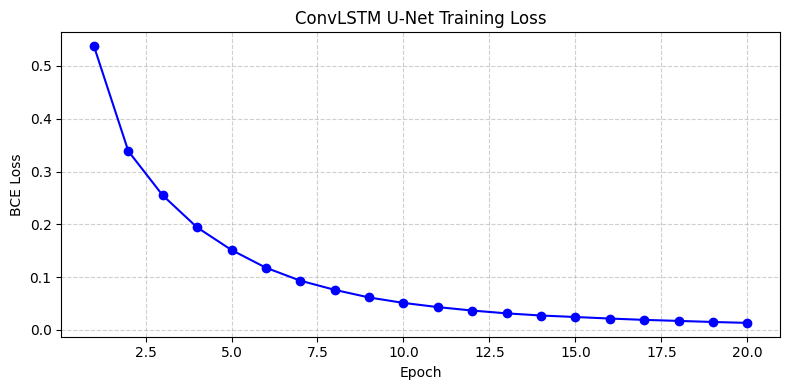

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), loss_history, marker='o', linestyle='-', color='b')
plt.title("ConvLSTM U-Net Training Loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [14]:
model.eval()

total_frames = len(thermal_volume)
test_indices = [
    max(SEQ_LEN - 1, int(total_frames * 0.15)),
    max(SEQ_LEN - 1, int(total_frames * 0.25)),
    max(SEQ_LEN - 1, int(total_frames * 0.50))
]

In [15]:
predictions = []
with torch.no_grad():
    for idx in test_indices:
        seq_slice = slice(idx - SEQ_LEN + 1, idx + 1)
        
        sample_in = np.stack([
            thermal_volume[seq_slice], 
            tsr_d1[seq_slice], 
            tsr_d2[seq_slice]
        ], axis=1)
        
        sample_tensor = torch.from_numpy(sample_in).unsqueeze(0).to(device)
        
        with torch.amp.autocast('cuda'):
            pred_seq_probs = torch.sigmoid(model(sample_tensor)).cpu().squeeze().numpy()
        
        pred_seq_mask = (pred_seq_probs > 0.5).astype(np.float32)
        predictions.append(pred_seq_mask[-1])

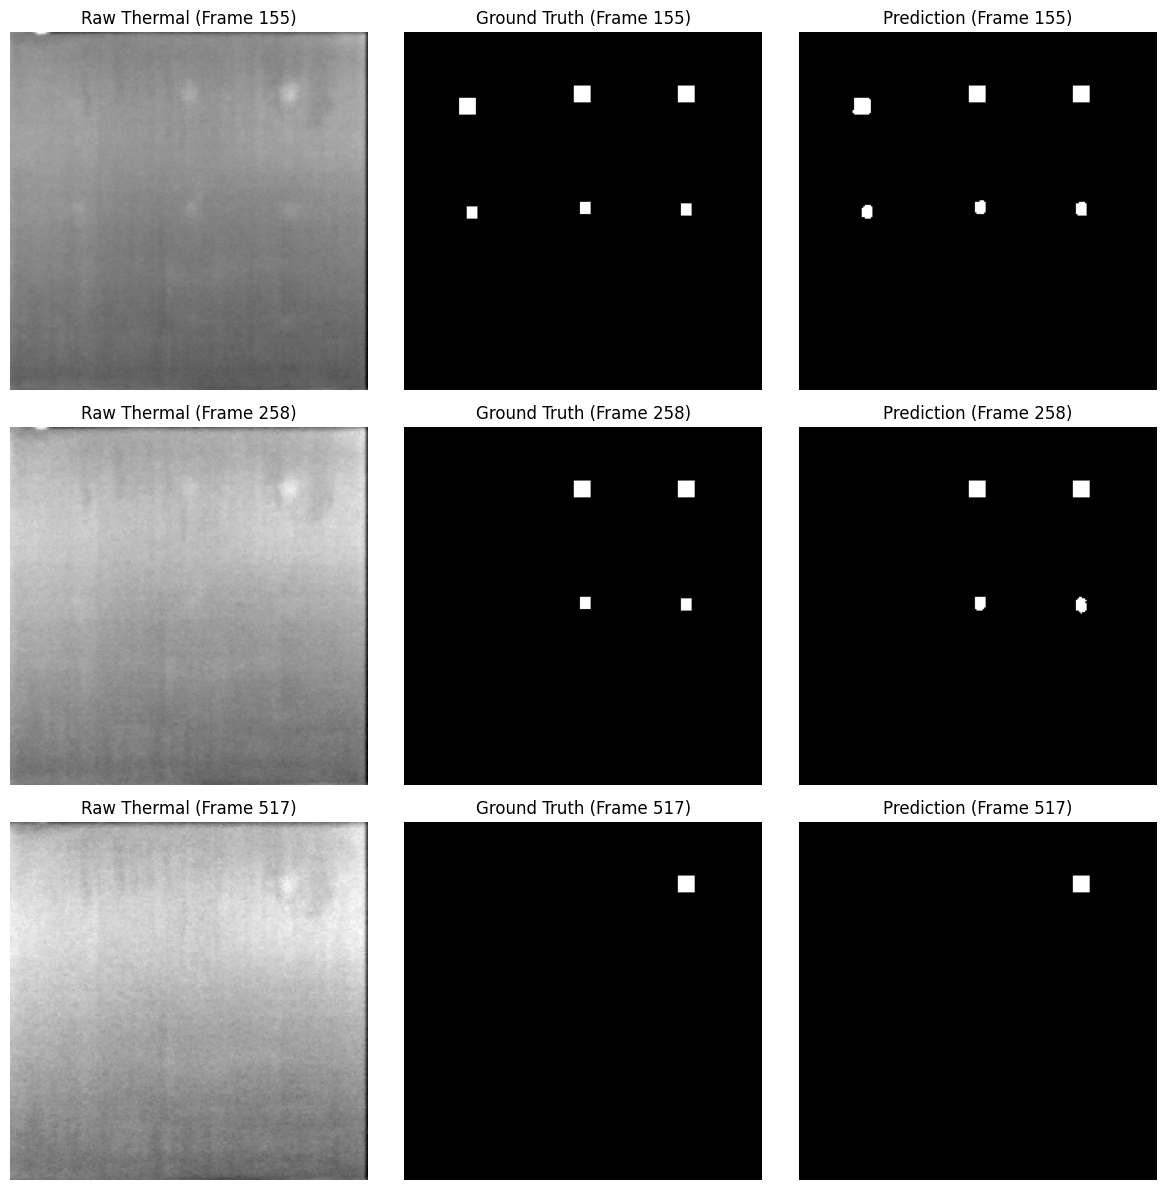

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for row, idx in enumerate(test_indices):
    axes[row, 0].imshow(thermal_volume[idx], cmap='gray')
    axes[row, 0].set_title(f"Raw Thermal (Frame {idx})")
    axes[row, 0].axis('off')

    axes[row, 1].imshow(mask_volume[idx], cmap='gray')
    axes[row, 1].set_title(f"Ground Truth (Frame {idx})")
    axes[row, 1].axis('off')

    axes[row, 2].imshow(predictions[row], cmap='gray')
    axes[row, 2].set_title(f"Prediction (Frame {idx})")
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()